# Método de Excedentes Fraccionarios Monocromático (MEFM)
---

Para adaptar el método de fracciones exactas descrito por T. Liu (1) al uso de una única longitud de onda debe tenerse un conocimiento previo del bloque patrón. Esto debido a que al utilizar una sola longitud de onda, la distancia ente cada posible valor valido para longitud real ($L_{real}$) es exactamente de $\lambda / 2$. En el caso de utilizar luz dentro del espectro visible, esto significa que las soluciones están separadas por unos 250 a 350 nanómetros.

Para seleccionar el valor "correcto" de $L_{real}$ a partir de una única longitud de onda se requiere que de la medición mecánica prelminar, que resulta en la longitud nominal ($L'$), tenga una incertidumbre total combinada estrictamente menor a $\pm \lambda / 4$. Si está incertudumbre es tan pequeña, el intervalo aceptable de error se reduce drasticamente. Matemáticamete, solo uno de los posibles valores generados por el método caerá dentro de esta estrecha franja de incertidumbre. En este escenario, una segunda o más longitudes de onda no son necesarias para confirmar la longitud obtenida, el único valor que entra en el rango es la solución "correcta".

In [72]:
%load_ext autoreload
%autoreload 2

import sys
import os
# Agrega el directorio padre (la raíz del repositorio) al path temporal de Python
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import matplotlib.pyplot as plt

from src.mefm_solver import MonochromaticEFMSolver

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
# incoming data
nominal_length = 10e6 # [nm]
delta_nominal_length = -150 # [nm]
uncertainty = 36.0 # [nm] U =(0.03 + 6*10^-4 * L mm)

# real length
fractional_real = 0.573

lambda_ = 632.9912 # [nm]

La relación entre $L_{real}$ y la longitud de onda de medida está dada por:

\begin{equation}
    L_{real} = (N_{real} + \epsilon_{real}) \frac{\lambda}{2},
\end{equation}

donde $N_{real}$ es la parte entera desconocida del orden de franja para la longitud de onda $\lambda$, $\epsilon_{real}$ es el valor de fraccional de franja previamente medido, cuyo valor está en el intervalo $[0, 1]$. Analogamente, la longitud de onda nominal puede expresarse como:

\begin{equation}
    L' = (N' + \epsilon') \frac{\lambda}{2},
\end{equation}

Para obtener la parte entera de la franja de interferencia $N_{real}$, es necesario primero obtener el valor de la parte fraccionaria correspondiente a la longitud nominal, es decir, $\epsilon'$:

\begin{equation}
    \epsilon' = \frac{2L'}{\lambda} - INT\bigg(\frac{2L'}{\lambda}\bigg),
\end{equation}

donde $INT(\cdot)$ es la función para obtener la parte entera.

In [74]:
fractional_prime, integral_prime = np.modf((2 * nominal_length) / lambda_)
print(f"Total: {2 * nominal_length / lambda_}")
print(f"Integral part: {integral_prime}")
print(f"Fractional part: {fractional_prime}")

Total: 31596.015868783008
Integral part: 31596.0
Fractional part: 0.015868783008045284


En lugar de intentar calcular directamente la parte entera fraccionaria, transformamos el problema a la determinación de la diferencia $c$ entre la parte nominal $L'$ y la parte entera $L_{entera}$, es decir, $c = L_{real} - L'$, luego:

\begin{equation}
    c = L_{real} - L' = (m + \delta)\frac{\lambda}{2}
\end{equation}

en donde $m\frac{\lambda}{2} = (N_{real} - N')\frac{\lambda}{2}$ es la parte entera de $c$ y $\delta\frac{\lambda}{2} = (\epsilon_{real} - \epsilon')\frac{\lambda}{2}$ es la parte fraccionaria de $c$ y ya está determinado por las condiciones expuestas. El problema se ha trasladado de deteminar la parte entera del orden de franja $N_{real}$ a determinar el valor de $c$. El máximo valor de desajuste permitido para $N'$ es:

\begin{equation}
    \Delta N' = INT \bigg(\frac{2\Delta L'_{error}}{\lambda}\bigg),
\end{equation}

en donde $\Delta L'_{error}$ es el rango de error de la longitud nominal. Luego, el valor de $m_j$ para la parte entera de $c$ se encuentra en el intervalo:

\begin{equation}
   -\Delta N' \leq m_j \leq \Delta N'
\end{equation}

Por tanto, el valor para la diferencia $c$ puede ser ajustado por la variable m_j como:

\begin{equation}
    c_j = (m_j + \delta) \frac{\lambda}{2}.
\end{equation}

El valor obtenido para c_j se compara con el intervalo deteminado por:

\begin{equation}
    [-L'_{error}, L'_{error}]
\end{equation}

In [75]:
# m_j = np.linspace(-int(2 * (delta_nominal_length + uncertainty) / lambda_), int(2 * (delta_nominal_length + uncertainty) / lambda_), num=10)
m_j = np.linspace(-3, 3, num=7)
print(f"m_j values: {m_j}")
difference = (lambda_ / 2) * (m_j + fractional_real - fractional_prime)
print(f"Difference: {difference}")

# acceptance interval
c = 0.0
lower_bound = delta_nominal_length - uncertainty
upper_bound = delta_nominal_length + uncertainty
for i in difference:
    if i > lower_bound and i < upper_bound:
       c = i
print(f"Lower bound: {lower_bound} nm")
print(f"Upper bound: {upper_bound} nm")
print(f"c difference value: {c}") 
    

m_j values: [-3. -2. -1.  0.  1.  2.  3.]
Difference: [-773.1572212 -456.6616212 -140.1660212  176.3295788  492.8251788
  809.3207788 1125.8163788]
Lower bound: -186.0 nm
Upper bound: -114.0 nm
c difference value: -140.16602119940111


Finalmente, con el valor de c_j encontrado y verificado en el intervalo de aceptancia, la longitud real del bloque puede calcularse como:

\begin{equation}
    L_{real} = L' + C_j
\end{equation}

Nota: La longitud, aunque se denota acá como longitud real, aún no esta calculada con las correcciones correspondientes.

In [76]:
L_real = nominal_length + c
print(f"Real length: {L_real} nm")

Real length: 9999859.8339788 nm


## Referencias

[1] T. Liu, J. Wu, R. Sato, H. Matsukuma, and W. Gao, Theoretical Analysis on Gauge Block Length Measurement by Excess Fraction Method, in 2022 8th International Conference on Nanomanufacturing & 4th AET Symposium on ACSM and Digital Manufacturing (Nanoman-AETS) (2022), pp. 1–7.

---
## Test del código empaquetado

In [77]:
he_ne_laser = MonochromaticEFMSolver(wavelength=632.9912)

# Evaluate the 10 mm block with the mechanical and optical data
try:
    result = he_ne_laser.evaluate_block(
        nominal_length=10e6,           
        delta_nominal_length=-150.0,   
        uncertainty=36.0,              
        measured_fraction=0.573        
    )
        
    print("Calibration Results:")
    print("-" * 20)
    print(f"Real Length:        {result['real_length_nm']:.3f} nm")
    print(f"Accepted c_j value: {result['c_difference_nm']} nm")
    print(f"Acceptance bounds:  {result['acceptance_interval']}")

except ValueError as e:
    print(f"Method Error: {e}")
except RuntimeError as e:
    print(f"Logic Error: {e}")

Calibration Results:
--------------------
Real Length:        9999859.834 nm
Accepted c_j value: -140.16602119940111 nm
Acceptance bounds:  (-186.0, -114.0)


---
### Ejemplo 2

In [78]:
he_ne_laser = MonochromaticEFMSolver(wavelength=543.5)

# Evaluate the 100 mm block with the mechanical and optical data
try:
    result = he_ne_laser.evaluate_block(
        nominal_length=100e6,           
        delta_nominal_length=-60.0,  # Tomado de certificado
        uncertainty=90.0,            # (0.03 + (6e-4)*100)*1e3 # nm | Tomado de certificado  
        measured_fraction=0.3908     # valor obtenido por el script para bloque de 100.0 mm
    )
        
    print("Calibration Results:")
    print("-" * 20)
    print(f"Real Length:        {result['real_length_nm']:.3f} nm")
    print(f"Accepted c_j value: {result['c_difference_nm']} nm")
    print(f"Acceptance bounds:  {result['acceptance_interval']}")

except ValueError as e:
    print(f"Method Error: {e}")
except RuntimeError as e:
    print(f"Logic Error: {e}")

Calibration Results:
--------------------
Real Length:        100000029.950 nm
Accepted c_j value: 29.94989999828287 nm
Acceptance bounds:  (-150.0, 30.0)


In [79]:
result['real_length_nm']*1e-6

np.float64(100.0000299499)

In [124]:
# variations on the wavelength
upper_limit = 543.5 + 0.5
lower_limit = 543.5 - 0.5
wavelengths = np.linspace(upper_limit, lower_limit, 2000)

lengths = []
wavelengths_pass = [] 

for i, wl in enumerate(wavelengths):
    try:
        he_ne_laser = MonochromaticEFMSolver(wavelength=wl)
        result = he_ne_laser.evaluate_block(
            nominal_length=100e6,        # [nm] | 100 [mm]    
            delta_nominal_length=-60.0,  # Tomado de certificado
            uncertainty=90.0,            # (0.03 + (6e-4)*100)*1e3 # nm | Tomado de certificado  
            measured_fraction=0.3908     # valor obtenido por el script para bloque de 100.0 mm
        )
        # print(i)
        lengths.append(result['real_length_nm'])
        wavelengths_pass.append(wl)
    except ValueError as e:
        print(f"Method Error: {e}")
    except RuntimeError as e:
        print(f"Logic Error: {e}")
        # print(f"Here {i}")
        # lengths.append(0.9e8)

Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optical value matches the mechanical measurement.
Logic Error: Convergence failure: No optica

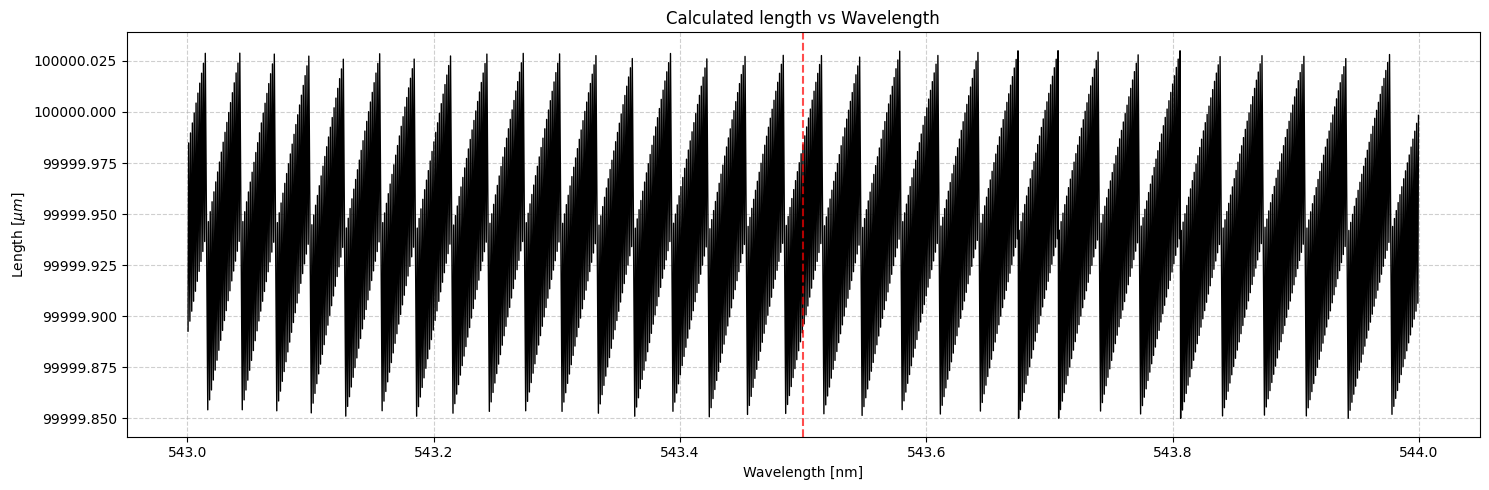

In [125]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(wavelengths_pass, np.array(lengths)*1e-3, color="k", linewidth=1.0)
ax.axvline(543.5,color='red', linestyle='--', alpha=0.7, 
            label=rf'Original $\epsilon_1$ = {543.5}' )

ax.set_title("Calculated length vs Wavelength", fontsize=12)
ax.set_xlabel("Wavelength [nm]", fontsize=10)
ax.set_ylabel(rf"Length [$\mu m$]", fontsize=10)

ax.get_yaxis().get_major_formatter().set_useOffset(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()